# Parte 1: Filtros

1\) (30%) Investigar/Consultar y definir los siguientes filtros (la investigación debe contener la fórmula matemática, un ejemplo y su explicación):


A. Filtro de media (Santiago)

B. Filtro de mediana(Ricardo)

C. Filtro logarítmico(Santiago)

D. Filtro de cuadro normalizado(Ricardo)

E. Filtro gaussiano(Santiago)

F. Filtro Laplace(Ricardo)

G. Filtro Sobel(Santiago)

H. Filtro Canny(Ricardo)


2\) De los filtros definidos en el numeral describir ventajas y desventajas

3\) De los filtros definidos en el numeral 1 programar un ejemplo usando opencv ó Matlab por cada literal  

#PARTE 2: (70%) Descriptores

- [ ] Generar un banco de imágenes  

- [ ] Hacer preprocesamiento a la imagen (mínimo resize o algún filtro de los estudiados)

- [ ] Definir características HOG y otra adicional SIFT, SURF, LAB, LBP(local binay patterns), gabor wavelets, Haralick  y extraer dichas características a las imágenes.

- [ ] Entrenar una red neuronal/svm  para cada set de características obtenidas en el punto anterior.

- [ ] Investigar métricas (por ejemplo: Accuracy, precisión, matriz de confusión, falsos positivos, falsos negativos, medidas F-Score)

- [ ] Aplicar el detector sobre nuevas imágenes y hacer una interfaz gráfica que cargue sus imágenes y aplique su clasificador

## Importación del datset

el datset utilizado fue [animals10](https://www.kaggle.com/datasets/alessiocorrado99/animals10)

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10


## Exploración de datos y traducción de las clases

In [1]:
import os
import pandas as pd
from collections import defaultdict

In [3]:
file_types = defaultdict(int)

print(f"Analizando tipos de archivos en: {path}")

for root, _, files in os.walk(path):
    for file in files:
        _, ext = os.path.splitext(file)
        file_types[ext.lower()] += 1

print("\nTipos de archivos encontrados y sus conteos:")
for ext, count in sorted(file_types.items()):
    print(f"  {ext}: {count}")

Analizando tipos de archivos en: /kaggle/input/animals10

Tipos de archivos encontrados y sus conteos:
  .jpeg: 24209
  .jpg: 1919
  .png: 51
  .py: 1


In [4]:
# Define the path to the images, assuming a 'raw-img' subdirectory
image_dir = os.path.join(path, 'raw-img')

# Dictionary to store class counts
class_counts = {}

# Iterate through class directories and count images
for class_name_italian in os.listdir(image_dir):
    class_path = os.path.join(image_dir, class_name_italian)
    if os.path.isdir(class_path):
        # Count only image files (e.g., .jpg, .jpeg, .png)
        num_images = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_counts[class_name_italian] = num_images

# Convert to DataFrame for easier manipulation and plotting
df_counts = pd.DataFrame(class_counts.items(), columns=['Class_Italian', 'Count'])

In [5]:
# Load the translate dictionary from the translate.py file
translate_file_path = os.path.join(path, 'translate.py')
with open(translate_file_path, 'r') as f:
    exec(f.read())
# Add missing translation for 'ragno' (spider in English)
if 'ragno' not in translate: # This check handles if translate.py is updated in the future
    translate['ragno'] = 'spider'

In [6]:
# Translate Italian class names to English
df_counts['Class_English'] = df_counts['Class_Italian'].map(translate)

# Sort by count for better visualization
df_counts = df_counts.sort_values(by='Count', ascending=False)

# Display the DataFrame with counts and translated names
display(df_counts)

,Class_Italian,Count,Class_English
8,cane,4863,dog
6,ragno,4821,spider
5,gallina,3098,chicken
0,cavallo,2623,horse
9,farfalla,2112,butterfly
7,mucca,1866,cow
4,scoiattolo,1862,squirrel
1,pecora,1820,sheep
3,gatto,1668,cat
2,elefante,1446,elephant


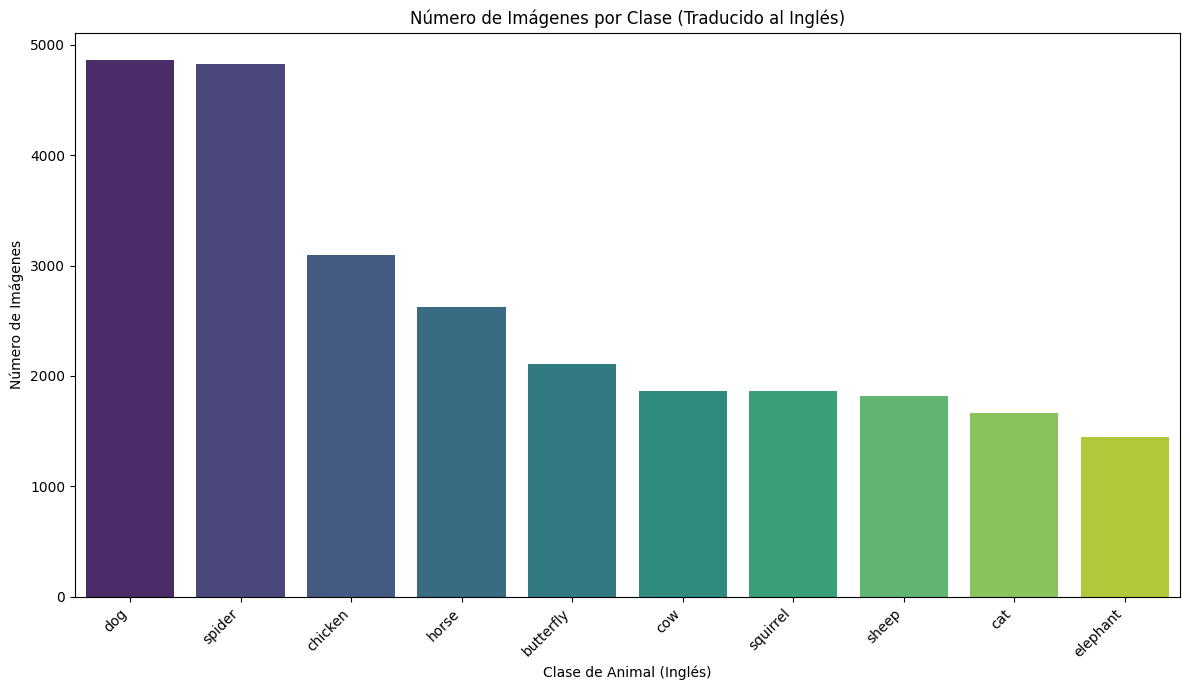

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='Class_English', y='Count', data=df_counts, palette='viridis', hue='Class_English', legend=False)
plt.title('Número de Imágenes por Clase (Traducido al Inglés)')
plt.xlabel('Clase de Animal (Inglés)')
plt.ylabel('Número de Imágenes')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Extracción de característcas HOG

In [10]:
import os
import numpy as np
import cv2 # Import OpenCV
# from skimage.io import imread # No longer needed
# from skimage.transform import resize # No longer needed
# from skimage.feature import hog # No longer needed
# from skimage.color import rgb2gray, rgba2rgb # No longer needed
from tqdm.notebook import tqdm
import joblib
from joblib import Parallel, delayed

# Define HOG parameters (OpenCV equivalent)
orientations = 9
pixels_per_cell = (8, 8)
cells_per_block = (2, 2)
transform_sqrt = True # This implies gamma correction
block_norm_type = cv2.HOGDescriptor_L2Hys # OpenCV specific norm type

# Define target image size for HOG
target_image_size = (128, 128) # winSize for HOGDescriptor

# Calculate blockSize and blockStride for OpenCV HOGDescriptor
blockSize = (cells_per_block[0] * pixels_per_cell[0], cells_per_block[1] * pixels_per_cell[1]) # (16, 16)
# For skimage, block stride is usually cell_size. Let's use (8,8) to be closer to skimage's behavior.
blockStride = (pixels_per_cell[0], pixels_per_cell[1])

# Function to process a single image and extract HOG features using OpenCV
def process_image_for_hog(image_path, class_name_english):
    try:
        # Initialize HOG descriptor inside the function for each worker process
        # This avoids pickling issues with cv2.HOGDescriptor
        hog_descriptor = cv2.HOGDescriptor(
            _winSize=target_image_size,
            _blockSize=blockSize,
            _blockStride=blockStride,
            _cellSize=pixels_per_cell,
            _nbins=orientations,
            _gammaCorrection=transform_sqrt,
            _histogramNormType=block_norm_type
        )

        # Read image using OpenCV
        image = cv2.imread(image_path)
        if image is None:
            raise FileNotFoundError(f"Image not found or cannot be read: {image_path}")

        # Resize the image
        resized_image = cv2.resize(image, target_image_size)

        # Convert to grayscale
        # OpenCV reads as BGR, so convert to grayscale
        gray_image = cv2.cvtColor(resized_image, cv2.COLOR_BGR2GRAY)

        # Compute HOG features. OpenCV HOGDescriptor.compute returns a flattened array.
        # It expects a CV_8U image. If the image is read correctly, it should be.
        hog_features = hog_descriptor.compute(gray_image)

        # The compute method returns a column vector, flatten it
        hog_features = hog_features.flatten()

        return hog_features, class_name_english
    except Exception as e:
        print(f"Error procesando la imagen {image_path}: {e}")
        return None, None

print("Comenzando la extracción de características HOG en paralelo con OpenCV...")

hog_features_list = []
labels_list = []

# Collect all image paths and their corresponding class names
# 'all_image_data' is already available from previous execution.
# If running as a standalone cell, it might need to be re-populated.
if 'all_image_data' not in locals():
    all_image_data = []
    for class_name_italian in os.listdir(image_dir):
        class_path = os.path.join(image_dir, class_name_italian)
        if os.path.isdir(class_path):
            class_name_english = translate.get(class_name_italian, 'Unknown')
            for image_filename in os.listdir(class_path):
                if image_filename.lower().endswith(('.png', '.jpg', '.jpeg')):
                    image_path = os.path.join(class_path, image_filename)
                    all_image_data.append((image_path, class_name_english))


results = Parallel(n_jobs=-1)(delayed(process_image_for_hog)(img_path, class_name)
                                for img_path, class_name in tqdm(all_image_data, desc="Extrayendo HOG con OpenCV"))

# Filter out any failed extractions and append to lists
for features, label in results:
    if features is not None:
        hog_features_list.append(features)
        labels_list.append(label)

print("Extracción de características HOG completada con OpenCV.")

Comenzando la extracción de características HOG en paralelo con OpenCV...


Extrayendo HOG con OpenCV:   0%|          | 0/26179 [00:00<?, ?it/s]

Extracción de características HOG completada con OpenCV.


### Guardar características HOG

In [11]:
# Convert lists to NumPy arrays
X = np.array(hog_features_list)
y = np.array(labels_list)

print(f"Forma del array de características (X): {X.shape}")
print(f"Forma del array de etiquetas (y): {y.shape}")

# Display a small sample of features and labels
print("\nPrimeras 5 filas de características HOG (parcial):")
print(X[:5, :10]) # Displaying first 10 dimensions for brevity
print("\nPrimeras 5 etiquetas:")
print(y[:5])

import joblib # Often used for saving ML-related objects
# Define paths to save the features and labels
# Change save_dir to a writable location, e.g., /content/
save_dir = os.path.join('/content/', 'processed_features')
os.makedirs(save_dir, exist_ok=True)

features_path = os.path.join(save_dir, 'hog_features.npy')
labels_path = os.path.join(save_dir, 'hog_labels.npy')

# Save the features and labels
np.save(features_path, X)
np.save(labels_path, y)

print(f"Características HOG guardadas en: {features_path}")
print(f"Etiquetas HOG guardadas en: {labels_path}")


Forma del array de características (X): (26179, 8100)
Forma del array de etiquetas (y): (26179,)

Primeras 5 filas de características HOG (parcial):
[[0.16477236 0.08292229 0.13699989 0.1679732  0.18352625 0.11821185
  0.13591425 0.13322403 0.12845875 0.20061553]
 [0.17591426 0.         0.         0.         0.33772385 0.
  0.07914415 0.02644859 0.17591426 0.59196806]
 [0.05779268 0.05231441 0.02693769 0.05788385 0.07495485 0.07554894
  0.0715695  0.07022105 0.08283939 0.02321857]
 [0.19274023 0.12965547 0.07075895 0.11168393 0.08418869 0.06011113
  0.1257008  0.1260128  0.2153137  0.23193567]
 [0.0075782  0.00834888 0.00894196 0.01484638 0.02875696 0.01111336
  0.00484756 0.00124443 0.00287901 0.02229729]]

Primeras 5 etiquetas:
['horse' 'horse' 'horse' 'horse' 'horse']
Características HOG guardadas en: /content/processed_features/hog_features.npy
Etiquetas HOG guardadas en: /content/processed_features/hog_labels.npy


## Extracción características LBP

In [12]:
import cv2
import numpy as np
from skimage.feature import local_binary_pattern
from tqdm.notebook import tqdm
import joblib
from joblib import Parallel, delayed
import os

# Define LBP parameters
LBP_RADIUS = 3
LBP_POINTS = 8 * LBP_RADIUS  # Typically 8 times the radius
LBP_METHOD = "uniform"       # "uniform" is recommended for reducing feature vector size

# Define target image size for LBP (consistent with HOG)
target_image_size = (128, 128)

# Function to preprocess and extract LBP features from a single image
def process_image_for_lbp(image_path, class_name_english):
    try:
        # Read image using OpenCV for better compatibility with different formats
        img = cv2.imread(image_path)
        if img is None:
            raise FileNotFoundError(f"Image not found or cannot be read: {image_path}")

        # Resize the image
        img = cv2.resize(img, target_image_size)

        # Convert to grayscale
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Apply histogram equalization for better contrast (optional but often beneficial)
        img_eq = cv2.equalizeHist(img_gray)

        # Extract LBP image
        lbp_image = local_binary_pattern(img_eq, P=LBP_POINTS,
                                         R=LBP_RADIUS, method=LBP_METHOD)

        # Calculate histogram of the LBP image as features
        # Number of bins depends on the LBP method. For 'uniform' LBP_POINTS + 2 unique patterns.
        n_bins = LBP_POINTS + 2 if LBP_METHOD == "uniform" else int(lbp_image.max()) + 1

        hist, _ = np.histogram(lbp_image.ravel(), bins=n_bins,
                               range=(0, n_bins), density=True) # density=True normalizes

        return hist, class_name_english
    except Exception as e:
        print(f"Error procesando la imagen {image_path}: {e}")
        return None, None

print("Comenzando la extracción de características LBP en paralelo...")

lbp_features_list = []
lbp_labels_list = []

# 'all_image_data' should already be populated from the HOG extraction section
# It's a list of (image_path, class_name_english) tuples

# Use joblib to parallelize the processing
results_lbp = Parallel(n_jobs=-1)(delayed(process_image_for_lbp)(img_path, class_name)
                                  for img_path, class_name in tqdm(all_image_data, desc="Extrayendo LBP"))

# Filter out any failed extractions and append to lists
for features, label in results_lbp:
    if features is not None:
        lbp_features_list.append(features)
        lbp_labels_list.append(label)

print("Extracción de características LBP completada.")



Comenzando la extracción de características LBP en paralelo...


Extrayendo LBP:   0%|          | 0/26179 [00:00<?, ?it/s]

Extracción de características LBP completada.


### Guardar características LBP

In [13]:
# Convert lists to NumPy arrays
X_lbp = np.array(lbp_features_list)
y_lbp = np.array(lbp_labels_list)

print(f"Forma del array de características LBP (X_lbp): {X_lbp.shape}")
print(f"Forma del array de etiquetas LBP (y_lbp): {y_lbp.shape}")

# Save the LBP features and labels
save_dir = os.path.join('/content/', 'processed_features')
os.makedirs(save_dir, exist_ok=True)

lbp_features_path = os.path.join(save_dir, 'lbp_features.npy')
lbp_labels_path = os.path.join(save_dir, 'lbp_labels.npy')

np.save(lbp_features_path, X_lbp)
np.save(lbp_labels_path, y_lbp)

print(f"Características LBP guardadas en: {lbp_features_path}")
print(f"Etiquetas LBP guardadas en: {lbp_labels_path}")

Forma del array de características LBP (X_lbp): (26179, 26)
Forma del array de etiquetas LBP (y_lbp): (26179,)
Características LBP guardadas en: /content/processed_features/lbp_features.npy
Etiquetas LBP guardadas en: /content/processed_features/lbp_labels.npy


# Entrenamiento MLP usando pytorch

## Cargar datos

In [2]:
import os
import torch
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Load the saved HOG features and labels
features_path = os.path.join(save_dir, 'hog_features.npy')
labels_path = os.path.join(save_dir, 'hog_labels.npy')

X_loaded = np.load(features_path)
y_loaded = np.load(labels_path)

print(f"Características HOG cargadas: {X_loaded.shape}")
print(f"Etiquetas HOG cargadas: {y_loaded.shape}")

# Encode labels to numerical format
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_loaded)
num_classes = len(label_encoder.classes_)
print(f"Número de clases: {num_classes}")

# Convert to PyTorch tensors
X_tensor = torch.tensor(X_loaded, dtype=torch.float32)
y_tensor = torch.tensor(y_encoded, dtype=torch.long)

print(f"Forma del tensor X: {X_tensor.shape}")
print(f"Forma del tensor y: {y_tensor.shape}")

NameError: name 'save_dir' is not defined

## Declarar mlp

In [15]:
import torch.nn as nn
import torch.nn.functional as F

# Define the Neural Network
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3) # Added dropout for regularization
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3) # Added dropout for regularization
        self.fc3 = nn.Linear(hidden_size2, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu1(out)
        out = self.dropout1(out)
        out = self.fc2(out)
        out = self.relu2(out)
        out = self.dropout2(out)
        out = self.fc3(out)
        return out

# Hyperparameters for the model
input_size = X_tensor.shape[1] # Number of HOG features
hidden_size1 = 512 # First hidden layer size
hidden_size2 = 256 # Second hidden layer size

print(f"Tamaño de entrada de la red: {input_size}")
print(f"Tamaño de la primera capa oculta: {hidden_size1}")
print(f"Tamaño de la segunda capa oculta: {hidden_size2}")
print(f"Número de clases de salida: {num_classes}")

Tamaño de entrada de la red: 8100
Tamaño de la primera capa oculta: 512
Tamaño de la segunda capa oculta: 256
Número de clases de salida: 10


## Entrenamiento usado validación cruzada

In [16]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, recall_score, precision_score
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Hyperparameters for training
num_epochs = 10
batch_size = 64
learning_rate = 0.001

# Initialize StratifiedKFold for cross-validation (10% for validation)
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

results = []

# Check for GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

for fold, (train_index, val_index) in enumerate(kf.split(X_tensor, y_tensor)):
    print(f"\n--- Fold {fold+1}/{kf.n_splits} ---")

    # Split data for the current fold
    X_train, X_val = X_tensor[train_index], X_tensor[val_index]
    y_train, y_val = y_tensor[train_index], y_tensor[val_index]

    # Create DataLoader for training and validation sets
    train_dataset = TensorDataset(X_train, y_train)
    val_dataset = TensorDataset(X_val, y_val)

    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(dataset=val_dataset, batch_size=batch_size, shuffle=False)

    # Initialize model, loss, and optimizer for each fold
    model = NeuralNet(input_size, hidden_size1, hidden_size2, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Training loop
    model.train()
    for epoch in range(num_epochs):
        for i, (images, labels) in enumerate(train_loader):
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Backward and optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        print (f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

    # Evaluation loop
    model.eval()
    with torch.no_grad():
        all_labels = []
        all_predictions = []
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())

        accuracy = accuracy_score(all_labels, all_predictions)
        # Use 'weighted' average for precision and recall for multiclass classification
        precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
        recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)

        print(f'Fold {fold+1} Validation Accuracy: {accuracy:.4f}')
        print(f'Fold {fold+1} Validation Sensitivity (Recall): {recall:.4f}')
        print(f'Fold {fold+1} Validation Precision: {precision:.4f}')

        results.append({
            'Fold': fold + 1,
            'Accuracy': accuracy,
            'Sensitivity': recall,
            'Precision': precision
        })

print("\nEntrenamiento con validación cruzada completado.")

Usando dispositivo: cpu

--- Fold 1/10 ---
Epoch [1/10], Loss: 2.3102
Epoch [2/10], Loss: 1.7501
Epoch [3/10], Loss: 1.3384
Epoch [4/10], Loss: 1.6718
Epoch [5/10], Loss: 1.8616
Epoch [6/10], Loss: 1.2081
Epoch [7/10], Loss: 1.4537
Epoch [8/10], Loss: 1.9468
Epoch [9/10], Loss: 1.3965
Epoch [10/10], Loss: 1.9641
Fold 1 Validation Accuracy: 0.4664
Fold 1 Validation Sensitivity (Recall): 0.4664
Fold 1 Validation Precision: 0.4925

--- Fold 2/10 ---
Epoch [1/10], Loss: 1.7485
Epoch [2/10], Loss: 1.9523
Epoch [3/10], Loss: 1.8742
Epoch [4/10], Loss: 1.8304
Epoch [5/10], Loss: 1.2678
Epoch [6/10], Loss: 1.6564
Epoch [7/10], Loss: 1.1930
Epoch [8/10], Loss: 1.9183
Epoch [9/10], Loss: 1.1408
Epoch [10/10], Loss: 1.7730
Fold 2 Validation Accuracy: 0.4530
Fold 2 Validation Sensitivity (Recall): 0.4530
Fold 2 Validation Precision: 0.4553

--- Fold 3/10 ---
Epoch [1/10], Loss: 1.6720
Epoch [2/10], Loss: 1.4732
Epoch [3/10], Loss: 1.8421
Epoch [4/10], Loss: 1.5851
Epoch [5/10], Loss: 1.6699
Epoch 

In [17]:
import pandas as pd

df_results = pd.DataFrame(results)
# Sort by accuracy in descending order
df_results_sorted = df_results.sort_values(by='Accuracy', ascending=False)

print("\nResumen de los resultados de validación cruzada:")
display(df_results_sorted)


Resumen de los resultados de validación cruzada:


,Fold,Accuracy,Sensitivity,Precision
0,1,0.466387,0.466387,0.492523
5,6,0.459129,0.459129,0.461712
1,2,0.453018,0.453018,0.455273
9,10,0.450134,0.450134,0.444751
6,7,0.449962,0.449962,0.442303
2,3,0.441558,0.441558,0.470493
3,4,0.438503,0.438503,0.442622
4,5,0.438121,0.438121,0.437579
7,8,0.427044,0.427044,0.457678
8,9,0.427044,0.427044,0.451350
